# STEP 1: Setup + Environment

### Cell 1: Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Cell 2: Define Grid World

In [2]:
grid_size = 4

start = (0, 0)
goal = (3, 3)
obstacles = [(1,1), (2,1)]

actions = ['up', 'down', 'left', 'right']
n_actions = len(actions)

# STEP 2: Rewards + Transitions

### Cell 3: Reward Function

In [3]:
def get_reward(state):
    if state in obstacles:
        return -10
    elif state == goal:
        return 10
    else:
        return -1

### Cell 4: State Transition Function

In [ ]:
def get_next_state(state, action):
    r, c = state

    if action == 0: r = max(r-1, 0)
    elif action == 1: r = min(r+1, grid_size-1)
    elif action == 2: c = max(c-1, 0)
    elif action == 3: c = min(c+1, grid_size-1)

    return (r, c)

# STEP 3: Initialize Q-Table

### Cell 5:

In [5]:
Q = np.zeros((grid_size, grid_size, n_actions))

### Cell 6:

In [6]:
alpha = 0.1
gamma = 0.9
epsilon = 0.2
episodes = 800

# STEP 5: Training

### Cell 7:

In [7]:
rewards_per_episode = []

for ep in range(episodes):
    state = start
    total_reward = 0

    while state != goal:
        
        # ε-greedy
        if np.random.rand() < epsilon:
            action = np.random.randint(n_actions)
        else:
            action = np.argmax(Q[state])

        next_state = get_next_state(state, action)
        reward = get_reward(next_state)

        # Q-update
        Q[state][action] += alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state][action]
        )

        state = next_state
        total_reward += reward

        if state in obstacles:
            break

    rewards_per_episode.append(total_reward)

# STEP 6: Learning Curve

### Cell 8:

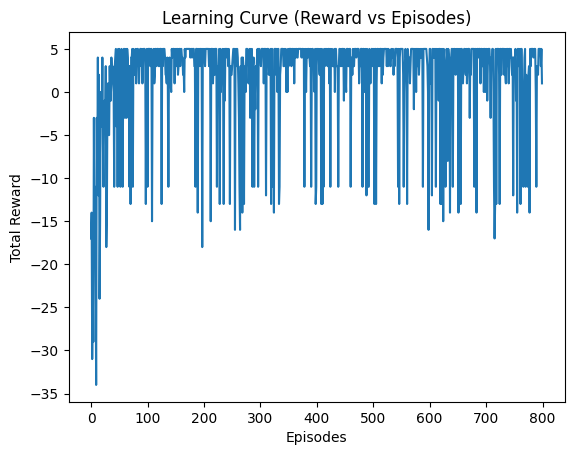

In [8]:
plt.figure()
plt.plot(rewards_per_episode)
plt.title("Learning Curve (Reward vs Episodes)")
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.show()

# STEP 7: Optimal Policy Extraction

### Cell 9:

In [9]:
policy = np.full((grid_size, grid_size), '')

symbols = ['↑', '↓', '←', '→']

for i in range(grid_size):
    for j in range(grid_size):
        if (i,j) in obstacles:
            policy[i,j] = 'X'
        elif (i,j) == goal:
            policy[i,j] = 'G'
        else:
            policy[i,j] = symbols[np.argmax(Q[i,j])]

print("Optimal Policy:\n", policy)

Optimal Policy:
 [['→' '→' '↓' '↓']
 ['↑' 'X' '→' '↓']
 ['↓' 'X' '→' '↓']
 ['→' '→' '→' 'G']]


# STEP 8: Optimal Path

### Cell 10:

In [10]:
state = start
path = [state]

while state != goal:
    action = np.argmax(Q[state])
    state = get_next_state(state, action)
    path.append(state)

print("Optimal Path:", path)

Optimal Path: [(0, 0), (0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 3)]


# STEP 9: Grid Visualization

### Cell 11:

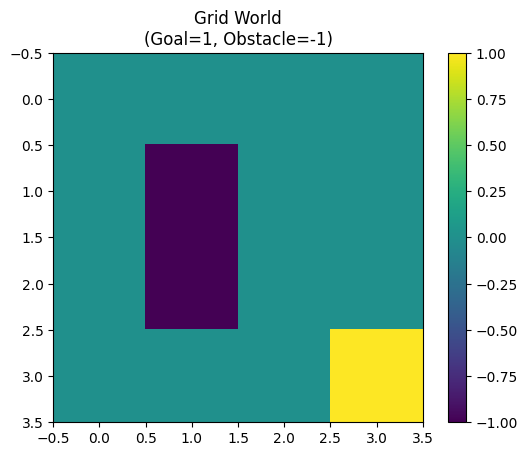

In [11]:
grid = np.zeros((grid_size, grid_size))

for (r,c) in obstacles:
    grid[r,c] = -1

grid[goal] = 1

plt.imshow(grid)
plt.title("Grid World\n(Goal=1, Obstacle=-1)")
plt.colorbar()
plt.show()

# STEP 10: Policy Visualization

### Cell 12:

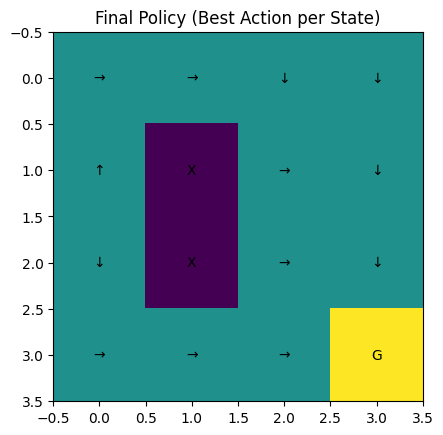

In [12]:
plt.figure()
plt.imshow(grid)

for i in range(grid_size):
    for j in range(grid_size):
        plt.text(j, i, policy[i,j], ha='center', va='center', color='black')

plt.title("Final Policy (Best Action per State)")
plt.show()

# STEP 11: Learning Behavior Analysis

### Cell 13:

In [13]:
print("\n===== ANALYSIS =====\n")

print("1. Initially, agent explores random actions.")
print("2. Over episodes, Q-values update using rewards.")
print("3. Negative reward (-1) encourages shortest path.")
print("4. Obstacle penalty (-10) avoids dangerous states.")
print("5. Agent converges to optimal policy.")


===== ANALYSIS =====

1. Initially, agent explores random actions.
2. Over episodes, Q-values update using rewards.
3. Negative reward (-1) encourages shortest path.
4. Obstacle penalty (-10) avoids dangerous states.
5. Agent converges to optimal policy.
